[INFO] Shapefile loaded successfully.
[INFO] model=fusion, lead=1, comp=u
[INFO] model=fusion, lead=1, comp=v
[INFO] model=fusion, lead=1, comp=w
[INFO] model=fusion, lead=2, comp=u
[INFO] model=fusion, lead=2, comp=v
[INFO] model=fusion, lead=2, comp=w
[INFO] model=fusion, lead=3, comp=u
[INFO] model=fusion, lead=3, comp=v
[INFO] model=fusion, lead=3, comp=w
[INFO] model=fusion, lead=4, comp=u
[INFO] model=fusion, lead=4, comp=v
[INFO] model=fusion, lead=4, comp=w
[INFO] model=fusion, lead=5, comp=u
[INFO] model=fusion, lead=5, comp=v
[INFO] model=fusion, lead=5, comp=w
[INFO] model=fusion, lead=6, comp=u
[INFO] model=fusion, lead=6, comp=v
[INFO] model=fusion, lead=6, comp=w
[INFO] model=noe, lead=1, comp=u
[INFO] model=noe, lead=1, comp=v
[INFO] model=noe, lead=1, comp=w
[INFO] model=noe, lead=2, comp=u
[INFO] model=noe, lead=2, comp=v
[INFO] model=noe, lead=2, comp=w
[INFO] model=noe, lead=3, comp=u
[INFO] model=noe, lead=3, comp=v
[INFO] model=noe, lead=3, comp=w
[INFO] model=noe,

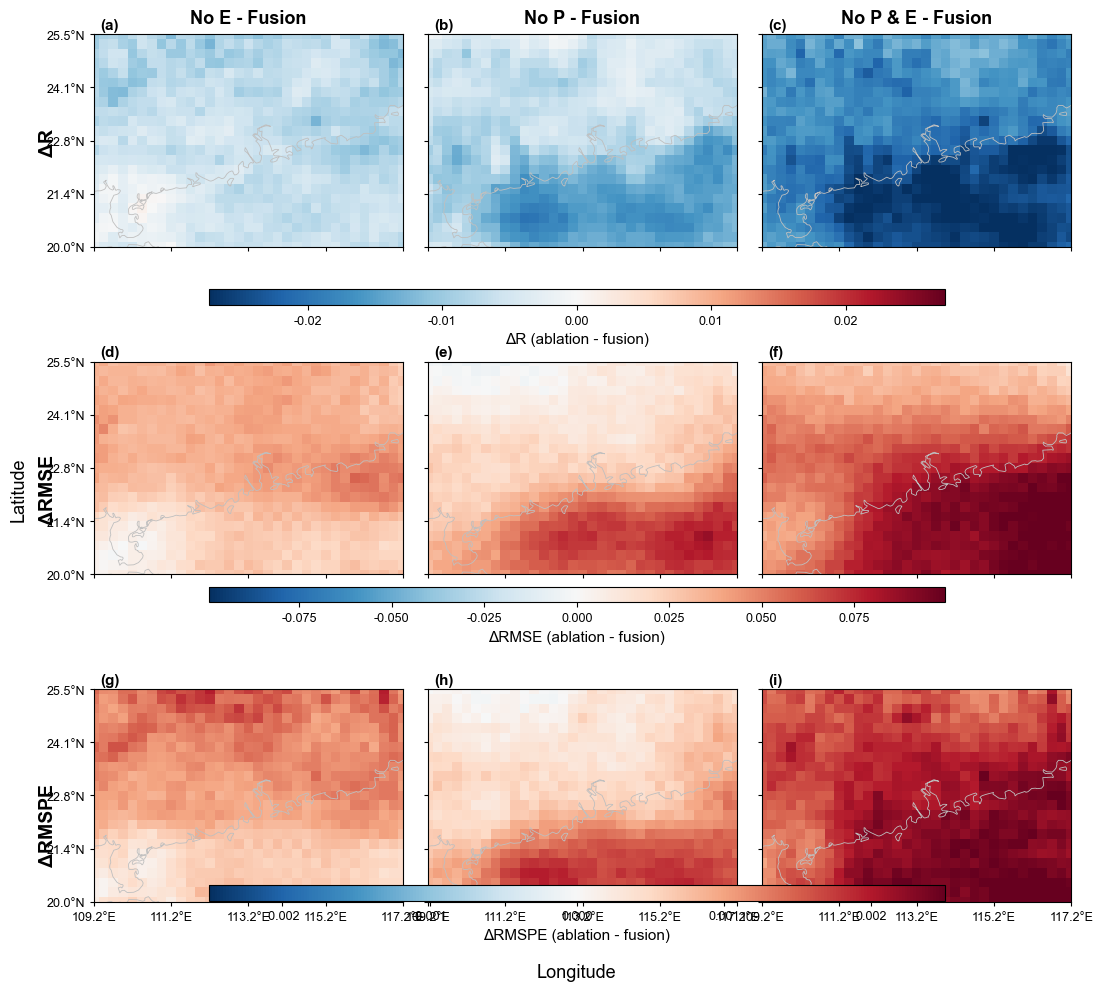


Done. Figure saved to:
E:/huawei/result/revised_figures\Supp_ablation_maps_regional_style_fixed.png


In [2]:
# -*- coding: utf-8 -*-
"""
Supplementary Figure:
Spatial differences between ablation experiments and the full fusion model

Rows:
    1 -> Delta R      = ablation - fusion
    2 -> Delta RMSE   = ablation - fusion
    3 -> Delta RMSPE  = ablation - fusion

Columns:
    1 -> noe  - fusion
    2 -> nop  - fusion
    3 -> nope - fusion

主要修正：
1. 区域范围严格限定到 nc 文件本身的经纬度范围
2. 保持区域图风格，而不是全球图
3. colorbar 单独布局，不与子图重合
"""

import os
import warnings
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import matplotlib.ticker as mticker

# =========================
# 1. 用户参数区
# =========================
RESULT_DIR = r'E:/huawei/result'
SAVE_DIR   = r'E:/huawei/result/revised_figures'
os.makedirs(SAVE_DIR, exist_ok=True)

# 若有边界 shp，可填写；没有则设为 None
SHP_PATH = r'F:/map/country1.shp'   # 没有就改成 None
USE_SHP = True if SHP_PATH is not None else False

# lead 时次
LEADS = [1, 2, 3, 4, 5, 6]

# 三个风分量
COMPONENTS = ['u', 'v', 'w']

# 模型后缀
MODEL_SUFFIXES = {
    'fusion': '',
    'noe': '_noe',
    'nop': '_nop',
    'nope': '_nope'
}

COL_TITLES = {
    'noe':  'No E - Fusion',
    'nop':  'No P - Fusion',
    'nope': 'No P & E - Fusion'
}

ROW_NAMES = ['ΔR', 'ΔRMSE', 'ΔRMSPE']
METRIC_ORDER = ['R', 'RMSE', 'RMSPE']
EXP_ORDER = ['noe', 'nop', 'nope']

# 颜色
CMAP = plt.cm.RdBu_r

# 字体风格
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 11

# =========================
# 2. 读取 shp（可选）
# =========================
gdf = None
if USE_SHP:
    try:
        import geopandas as gpd
        gdf = gpd.read_file(SHP_PATH)
        print('[INFO] Shapefile loaded successfully.')
    except Exception as e:
        print(f'[WARN] Shapefile load failed, continue without it: {e}')
        gdf = None


# =========================
# 3. 文件路径与变量名
# =========================
def build_file_path(component, lead, suffix, kind='true'):
    """
    component: 'u'/'v'/'w'
    lead: 1~6
    suffix: '', '_noe', '_nop', '_nope'
    kind: 'true' or 'pred'
    """
    if kind == 'true':
        if component == 'u':
            # u 的 test 文件名少了 y
            filename = f'cnn_transformer_test_u_{lead}_5year_order_fusion{suffix}.nc'
        elif component == 'v':
            filename = f'cnn_transformer_testy_v_{lead}_5year_order_fusion{suffix}.nc'
        elif component == 'w':
            filename = f'cnn_transformer_testy_w_{lead}_5year_order_fusion{suffix}.nc'
        else:
            raise ValueError(f'Unknown component: {component}')
    else:
        filename = f'cnn_transformer_predicty_{component}_{lead}_5year_order_fusion{suffix}.nc'

    return os.path.join(RESULT_DIR, filename)


def get_var_name(component, kind='true'):
    if kind == 'true':
        return f'testy_{component}'
    else:
        return f'predicty_{component}'


# =========================
# 4. 统一维度名称
# =========================
def standardize_da(da):
    """
    统一维度名为:
    time / level / lat / lon
    """
    rename_dict = {}
    for d in da.dims:
        dl = d.lower()
        if dl in ['time', 'valid_time']:
            rename_dict[d] = 'time'
        elif dl in ['level', 'lev', 'pressure', 'plev']:
            rename_dict[d] = 'level'
        elif dl in ['latitude', 'lat', 'y']:
            rename_dict[d] = 'lat'
        elif dl in ['longitude', 'lon', 'x']:
            rename_dict[d] = 'lon'

    da = da.rename(rename_dict)

    # 如果没有 level，就补一个
    if 'level' not in da.dims:
        da = da.expand_dims(level=[0])

    # 排序，保证 lat/lon 单调
    if 'lat' in da.coords:
        da = da.sortby('lat')
    if 'lon' in da.coords:
        da = da.sortby('lon')

    # 统一维度顺序
    dims = [d for d in ['time', 'level', 'lat', 'lon'] if d in da.dims]
    da = da.transpose(*dims)

    return da


# =========================
# 5. 读取一组真值和预测
# =========================
def load_pair(component, lead, suffix):
    true_path = build_file_path(component, lead, suffix, kind='true')
    pred_path = build_file_path(component, lead, suffix, kind='pred')

    true_var = get_var_name(component, kind='true')
    pred_var = get_var_name(component, kind='pred')

    if not os.path.exists(true_path):
        raise FileNotFoundError(f'Missing file: {true_path}')
    if not os.path.exists(pred_path):
        raise FileNotFoundError(f'Missing file: {pred_path}')

    ds_true = xr.open_dataset(true_path)
    ds_pred = xr.open_dataset(pred_path)

    da_true = standardize_da(ds_true[true_var])
    da_pred = standardize_da(ds_pred[pred_var])

    # 对齐坐标
    da_true, da_pred = xr.align(da_true, da_pred, join='inner')

    obs = da_true.values
    pred = da_pred.values
    lat = da_true['lat'].values
    lon = da_true['lon'].values

    return obs, pred, lat, lon


# =========================
# 6. 逐格点计算指标
# =========================
def calc_grid_metrics(obs, pred, eps=1e-12):
    """
    输入:
        obs, pred: [time, level, lat, lon]

    返回:
        r_2d, rmse_2d, rmspe_2d: [lat, lon]

    逻辑:
    1) 对每个(level, lat, lon)沿 time 算指标
    2) 再对 level 平均
    """
    obs = np.asarray(obs, dtype=np.float64)
    pred = np.asarray(pred, dtype=np.float64)

    valid = np.isfinite(obs) & np.isfinite(pred)
    obsv = np.where(valid, obs, np.nan)
    predv = np.where(valid, pred, np.nan)

    count = np.sum(valid, axis=0)  # [level, lat, lon]

    # ---- R ----
    obs_mean = np.nanmean(obsv, axis=0)
    pred_mean = np.nanmean(predv, axis=0)

    obs_anom = obsv - obs_mean
    pred_anom = predv - pred_mean

    cov = np.nanmean(obs_anom * pred_anom, axis=0)
    obs_std = np.nanstd(obsv, axis=0)
    pred_std = np.nanstd(predv, axis=0)

    r = cov / (obs_std * pred_std)
    r[(count < 2) | (obs_std <= 0) | (pred_std <= 0)] = np.nan

    # ---- RMSE ----
    rmse = np.sqrt(np.nanmean((predv - obsv) ** 2, axis=0))
    rmse[count < 1] = np.nan

    # ---- RMSPE ----
    # 这里严格按你之前的定义：RMSE / (max(testy)-min(testy))
    obs_range = np.nanmax(obsv, axis=0) - np.nanmin(obsv, axis=0)
    rmspe = rmse / (obs_range + eps)
    rmspe[(count < 1) | (obs_range <= 0)] = np.nan

    # 对 level 平均，得到二维图
    r_2d = np.nanmean(r, axis=0)
    rmse_2d = np.nanmean(rmse, axis=0)
    rmspe_2d = np.nanmean(rmspe, axis=0)

    return r_2d, rmse_2d, rmspe_2d


# =========================
# 7. 聚合一个模型的所有 lead + 所有风
# =========================
def aggregate_model_maps(model_key):
    suffix = MODEL_SUFFIXES[model_key]

    r_list = []
    rmse_list = []
    rmspe_list = []

    lat_ref = None
    lon_ref = None

    for lead in LEADS:
        for comp in COMPONENTS:
            print(f'[INFO] model={model_key}, lead={lead}, comp={comp}')

            obs, pred, lat, lon = load_pair(comp, lead, suffix)

            if lat_ref is None:
                lat_ref = lat
                lon_ref = lon
            else:
                if len(lat) != len(lat_ref) or len(lon) != len(lon_ref):
                    raise ValueError(
                        f'Coordinate size mismatch in model={model_key}, lead={lead}, comp={comp}'
                    )

            r2d, rmse2d, rmspe2d = calc_grid_metrics(obs, pred)

            r_list.append(r2d)
            rmse_list.append(rmse2d)
            rmspe_list.append(rmspe2d)

    out = {
        'R': np.nanmean(np.stack(r_list, axis=0), axis=0),
        'RMSE': np.nanmean(np.stack(rmse_list, axis=0), axis=0),
        'RMSPE': np.nanmean(np.stack(rmspe_list, axis=0), axis=0),
        'lat': lat_ref,
        'lon': lon_ref
    }
    return out


# =========================
# 8. 计算所有模型
# =========================
all_maps = {}
for mk in ['fusion', 'noe', 'nop', 'nope']:
    all_maps[mk] = aggregate_model_maps(mk)

lat = all_maps['fusion']['lat']
lon = all_maps['fusion']['lon']

# 严格使用 nc 文件本身范围
LON_MIN, LON_MAX = np.nanmin(lon), np.nanmax(lon)
LAT_MIN, LAT_MAX = np.nanmin(lat), np.nanmax(lat)

print(f'[INFO] Plot extent from NC: lon={LON_MIN}~{LON_MAX}, lat={LAT_MIN}~{LAT_MAX}')

# 差值图：ablation - fusion
diff_maps = {
    'R': {
        'noe':  all_maps['noe']['R']    - all_maps['fusion']['R'],
        'nop':  all_maps['nop']['R']    - all_maps['fusion']['R'],
        'nope': all_maps['nope']['R']   - all_maps['fusion']['R']
    },
    'RMSE': {
        'noe':  all_maps['noe']['RMSE']  - all_maps['fusion']['RMSE'],
        'nop':  all_maps['nop']['RMSE']  - all_maps['fusion']['RMSE'],
        'nope': all_maps['nope']['RMSE'] - all_maps['fusion']['RMSE']
    },
    'RMSPE': {
        'noe':  all_maps['noe']['RMSPE']  - all_maps['fusion']['RMSPE'],
        'nop':  all_maps['nop']['RMSPE']  - all_maps['fusion']['RMSPE'],
        'nope': all_maps['nope']['RMSPE'] - all_maps['fusion']['RMSPE']
    }
}


# =========================
# 9. 作图辅助函数
# =========================
def get_symmetric_vmax(diff_dict_row, q=98):
    """
    为某一行(metric)统一色标范围
    用 98 分位避免极端值影响太大
    """
    arrs = []
    for k in EXP_ORDER:
        arrs.append(diff_dict_row[k].ravel())
    arr = np.concatenate(arrs)
    arr = arr[np.isfinite(arr)]

    if arr.size == 0:
        return 1e-6

    vmax = np.nanpercentile(np.abs(arr), q)
    if (not np.isfinite(vmax)) or (vmax == 0):
        vmax = np.nanmax(np.abs(arr))
    if (not np.isfinite(vmax)) or (vmax == 0):
        vmax = 1e-6
    return vmax


def nice_ticks(vmin, vmax, n=5):
    return np.linspace(vmin, vmax, n)


# =========================
# 10. 开始作图
# =========================
fig, axes = plt.subplots(
    3, 3,
    figsize=(11.5, 10.5),
    sharex=True,
    sharey=True
)

panel_labels = ['(a)', '(b)', '(c)',
                '(d)', '(e)', '(f)',
                '(g)', '(h)', '(i)']

row_mappables = []

for i, metric in enumerate(METRIC_ORDER):
    vmax = get_symmetric_vmax(diff_maps[metric], q=98)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

    last_pm = None

    for j, exp_name in enumerate(EXP_ORDER):
        ax = axes[i, j]
        data = diff_maps[metric][exp_name]

        # 核心图
        pm = ax.pcolormesh(
            lon, lat, data,
            shading='auto',
            cmap=CMAP,
            norm=norm
        )
        last_pm = pm

        # 叠加 shapefile 边界（若有）
        if gdf is not None:
            try:
                gdf.boundary.plot(ax=ax, color='0.75', linewidth=0.6)
            except Exception as e:
                warnings.warn(f'Shapefile plot failed: {e}')

        # 关键修正：强制把范围拉回 nc 文件区域，而不是全局
        ax.set_xlim(LON_MIN, LON_MAX)
        ax.set_ylim(LAT_MIN, LAT_MAX)

        # 子图标签
        ax.text(
            0.02, 1.01, panel_labels[i * 3 + j],
            transform=ax.transAxes,
            ha='left', va='bottom',
            fontsize=11, fontweight='bold'
        )

        # 列标题
        if i == 0:
            ax.set_title(COL_TITLES[exp_name], fontsize=13, fontweight='bold', pad=8)

        # 边框和刻度风格
        ax.tick_params(labelsize=9, direction='out', length=3, width=0.8)
        ax.spines['top'].set_visible(True)
        ax.spines['right'].set_visible(True)

        # 只有左列显示纬度刻度标签
        if j != 0:
            ax.tick_params(labelleft=False)

        # 只有底行显示经度刻度标签
        if i != 2:
            ax.tick_params(labelbottom=False)

    row_mappables.append(last_pm)

# =========================
# 11. 坐标刻度设置
# =========================
xticks = nice_ticks(LON_MIN, LON_MAX, n=5)
yticks = nice_ticks(LAT_MIN, LAT_MAX, n=5)

for ax in axes[-1, :]:
    ax.set_xticks(xticks)
    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f°E'))

for ax in axes[:, 0]:
    ax.set_yticks(yticks)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f°N'))

# 外侧大标签（模仿你之前那种风格）
fig.text(0.04, 0.83, 'ΔR', rotation=90, va='center', ha='center',
         fontsize=14, fontweight='bold')
fig.text(0.04, 0.50, 'ΔRMSE', rotation=90, va='center', ha='center',
         fontsize=14, fontweight='bold')
fig.text(0.04, 0.18, 'ΔRMSPE', rotation=90, va='center', ha='center',
         fontsize=14, fontweight='bold')

fig.text(0.5, 0.04, 'Longitude', ha='center', va='center',
         fontsize=13)
fig.text(0.015, 0.5, 'Latitude', ha='center', va='center',
         rotation=90, fontsize=13)

# =========================
# 12. 布局调整（给 colorbar 留空间）
# =========================
plt.subplots_adjust(
    left=0.08,
    right=0.93,
    bottom=0.09,
    top=0.95,
    wspace=0.08,
    hspace=0.32
)

# =========================
# 13. 每一行加一个 colorbar（不与图重合）
# =========================
# 手动定义三个 colorbar 位置，更稳
cax1 = fig.add_axes([0.18, 0.675, 0.64, 0.015])  # [left, bottom, width, height]
cax2 = fig.add_axes([0.18, 0.392, 0.64, 0.015])
cax3 = fig.add_axes([0.18, 0.108, 0.64, 0.015])

cbars = []
cbars.append(fig.colorbar(row_mappables[0], cax=cax1, orientation='horizontal'))
cbars.append(fig.colorbar(row_mappables[1], cax=cax2, orientation='horizontal'))
cbars.append(fig.colorbar(row_mappables[2], cax=cax3, orientation='horizontal'))

cbars[0].set_label('ΔR (ablation - fusion)', fontsize=11)
cbars[1].set_label('ΔRMSE (ablation - fusion)', fontsize=11)
cbars[2].set_label('ΔRMSPE (ablation - fusion)', fontsize=11)

for cb in cbars:
    cb.ax.tick_params(labelsize=9)

# =========================
# 14. 保存
# =========================
save_path = os.path.join(SAVE_DIR, 'Supp_ablation_maps_regional_style_fixed.png')
plt.savefig(save_path, dpi=600, bbox_inches='tight')
plt.show()

print(f'\nDone. Figure saved to:\n{save_path}')

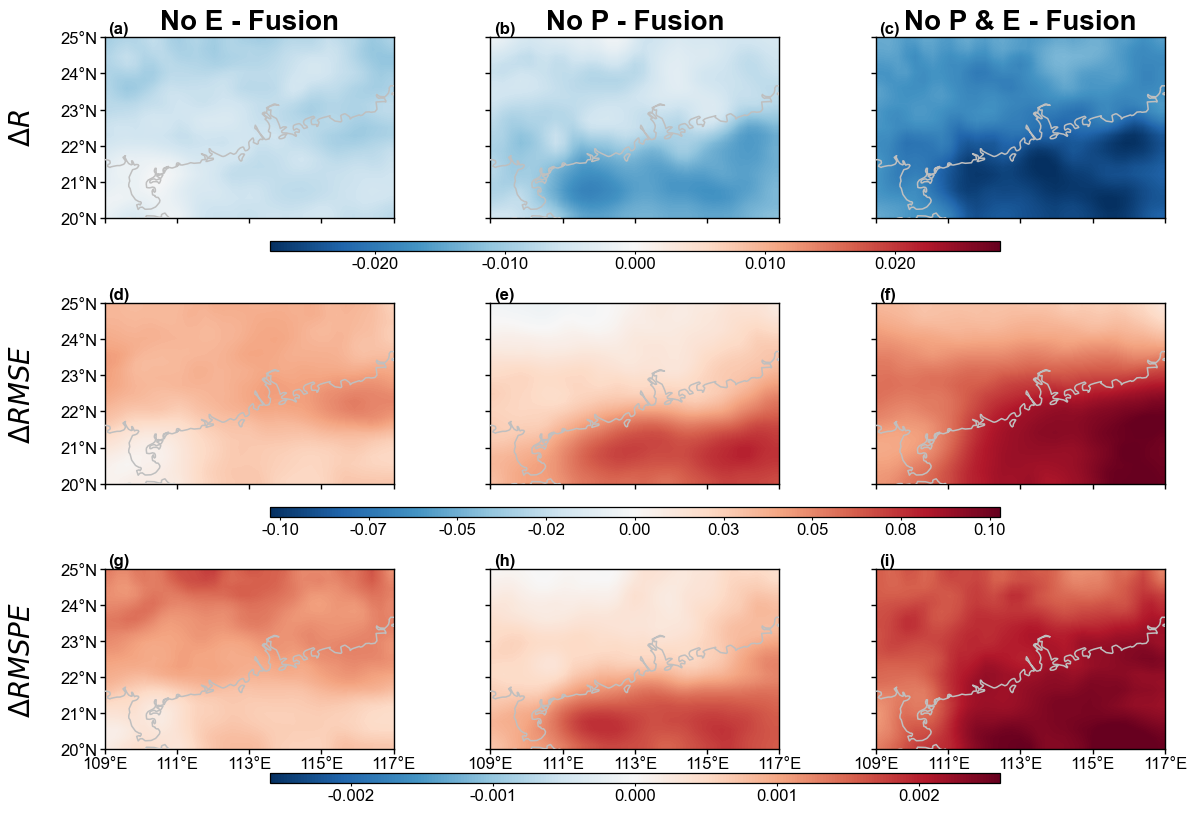

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import FuncFormatter, FormatStrFormatter
from scipy.ndimage import gaussian_filter

def plot_ablation_maps(
    diff_maps,
    outline_gdf=None,
    save_path=None,
    figsize=(12.2, 8.8),
    smooth_sigma=0.9,
):
    """
    diff_maps 结构必须为：
    diff_maps = {
        'R': {
            'noe': 2d_array,
            'nop': 2d_array,
            'nope': 2d_array
        },
        'RMSE': {
            'noe': 2d_array,
            'nop': 2d_array,
            'nope': 2d_array
        },
        'RMSPE': {
            'noe': 2d_array,
            'nop': 2d_array,
            'nope': 2d_array
        }
    }
    """

    # =========================
    # 1. 可调参数
    # =========================
    LEFT   = 0.078
    RIGHT  = 0.985
    TOP    = 0.955
    BOTTOM = 0.078

    # 子图水平/垂直间距
    WSPACE = 0.15
    HSPACE = 0.3

    # colorbar 单独行的高度
    HEIGHT_RATIOS = [1.00, 0.13,
                     1.00, 0.13,
                     1.00, 0.16]

    # colorbar 左右缩进（相对整行）
    CBAR_LEFT_SHRINK  = 0.17
    CBAR_RIGHT_SHRINK = 0.17

    # 前两行与最后一行 colorbar 的纵向位置
    CBAR_Y_REL_ROW12 = 0.9
    CBAR_Y_REL_ROW3  = 0.9

    # colorbar 自身高度缩放
    CBAR_HEIGHT_SCALE_ROW12 = 0.42
    CBAR_HEIGHT_SCALE_ROW3  = 0.36

    # 字体
    COL_TITLE_FS   = 20
    PANEL_LABEL_FS = 12
    TICK_FS        = 12
    CBAR_TICK_FS   = 12
    ROWLABEL_FS    = 20

    # 左侧大标签位置
    ROWLABEL_X = 0.030

    # 边界线
    OUTLINE_COLOR = "0.75"
    OUTLINE_LW    = 1.1

    # 区域范围和刻度
    XMIN, XMAX = 109.0, 117.0
    YMIN, YMAX = 20.0, 25.0
    XTICKS = np.arange(109, 118, 2)   # 109,111,113,115,117
    YTICKS = np.arange(20, 26, 1)     # 20,21,22,23,24,25

    # panel 标签
    panel_labels = ['(a)', '(b)', '(c)',
                    '(d)', '(e)', '(f)',
                    '(g)', '(h)', '(i)']

    col_titles = ['No E - Fusion', 'No P - Fusion', 'No P & E - Fusion']
    row_big_labels = [r'$\Delta R$', r'$\Delta RMSE$', r'$\Delta RMSPE$']

    cmap = plt.cm.RdBu_r

    # =========================
    # 2. 基础检查
    # =========================
    for key in ['R', 'RMSE', 'RMSPE']:
        if key not in diff_maps:
            raise ValueError(f"diff_maps 缺少键: {key}")
        for sub in ['noe', 'nop', 'nope']:
            if sub not in diff_maps[key]:
                raise ValueError(f"diff_maps['{key}'] 缺少键: {sub}")

    # =========================
    # 3. 工具函数
    # =========================
    def lon_formatter(x, pos):
        return f"{int(round(x))}°E"

    def lat_formatter(y, pos):
        return f"{int(round(y))}°N"

    def smooth_nan_field(arr, sigma=1.0):
        arr = np.asarray(arr, dtype=float)
        if sigma is None or sigma <= 0:
            return arr.copy()

        valid = np.isfinite(arr)
        if valid.sum() == 0:
            return arr.copy()

        filled = np.where(valid, arr, np.nanmean(arr))
        smooth_val = gaussian_filter(filled, sigma=sigma)
        smooth_w   = gaussian_filter(valid.astype(float), sigma=sigma)
        out = smooth_val / np.where(smooth_w == 0, np.nan, smooth_w)
        return out

    def robust_symmetric_limit(arr_list, q=99):
        vals = []
        for a in arr_list:
            x = np.asarray(a, dtype=float)
            x = x[np.isfinite(x)]
            if x.size > 0:
                vals.append(np.abs(x))
        if len(vals) == 0:
            return -1.0, 1.0
        vals = np.concatenate(vals)
        vmax = np.nanpercentile(vals, q)
        if not np.isfinite(vmax) or vmax == 0:
            vmax = np.nanmax(vals)
        if not np.isfinite(vmax) or vmax == 0:
            vmax = 1.0
        return -vmax, vmax

    def get_fmt(vmax):
        if vmax < 0.01:
            return "%.3f"
        elif vmax < 0.1:
            return "%.3f"
        else:
            return "%.2f"

    def draw_outline(ax):
        if outline_gdf is None:
            return
        try:
            outline_gdf.boundary.plot(
                ax=ax, color=OUTLINE_COLOR, linewidth=OUTLINE_LW, zorder=5
            )
        except Exception:
            try:
                outline_gdf.plot(
                    ax=ax, color=OUTLINE_COLOR, linewidth=OUTLINE_LW, zorder=5
                )
            except Exception:
                pass

    # =========================
    # 4. 数据组织
    # =========================
    plot_data = [
        [diff_maps['R']['noe'],     diff_maps['R']['nop'],     diff_maps['R']['nope']],
        [diff_maps['RMSE']['noe'],  diff_maps['RMSE']['nop'],  diff_maps['RMSE']['nope']],
        [diff_maps['RMSPE']['noe'], diff_maps['RMSPE']['nop'], diff_maps['RMSPE']['nope']],
    ]

    row_limits = [robust_symmetric_limit(row, q=99) for row in plot_data]

    # =========================
    # 5. 全局字体风格
    # =========================
    plt.rcParams.update({
        "font.family": "Arial",
        "font.size": 10,
        "axes.linewidth": 1.0,
        "xtick.labelsize": TICK_FS,
        "ytick.labelsize": TICK_FS,
    })

    # =========================
    # 6. 建图
    # =========================
    fig = plt.figure(figsize=figsize)

    gs = GridSpec(
        nrows=6, ncols=3, figure=fig,
        height_ratios=HEIGHT_RATIOS,
        left=LEFT, right=RIGHT, top=TOP, bottom=BOTTOM,
        wspace=WSPACE, hspace=HSPACE
    )

    axes = [[None]*3 for _ in range(3)]
    cbar_axes = [None]*3

    # 地图子图
    ref_ax = None
    for i in range(3):
        for j in range(3):
            row_idx = i * 2
            if ref_ax is None:
                ax = fig.add_subplot(gs[row_idx, j])
                ref_ax = ax
            else:
                ax = fig.add_subplot(gs[row_idx, j], sharex=ref_ax, sharey=ref_ax)
            axes[i][j] = ax

    # colorbar 子图
    for i in range(3):
        cax = fig.add_subplot(gs[i*2 + 1, :])
        cbar_axes[i] = cax

    # =========================
    # 7. 画 3x3 地图
    # =========================
    row_mappables = []

    for irow in range(3):
        vmin, vmax = row_limits[irow]
        first_im = None

        for icol in range(3):
            ax = axes[irow][icol]
            arr = smooth_nan_field(plot_data[irow][icol], sigma=smooth_sigma)

            # 直接用固定 extent，彻底避免子图内部左边白边
            im = ax.imshow(
                arr,
                origin="lower",
                extent=[XMIN, XMAX, YMIN, YMAX],
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                interpolation="bilinear",
                aspect="auto",
                zorder=1
            )

            if first_im is None:
                first_im = im

            draw_outline(ax)

            ax.set_xlim(XMIN, XMAX)
            ax.set_ylim(YMIN, YMAX)

            ax.set_xticks(XTICKS)
            ax.set_yticks(YTICKS)
            ax.xaxis.set_major_formatter(FuncFormatter(lon_formatter))
            ax.yaxis.set_major_formatter(FuncFormatter(lat_formatter))

            if icol != 0:
                ax.tick_params(axis='y', labelleft=False)
            if irow != 2:
                ax.tick_params(axis='x', labelbottom=False)

            ax.tick_params(axis='both', labelsize=TICK_FS, length=3.5, width=1.0, pad=1.5)

            # panel label
            pidx = irow * 3 + icol
            ax.text(
                0.012, 1.005, panel_labels[pidx],
                transform=ax.transAxes,
                ha="left", va="bottom",
                fontsize=PANEL_LABEL_FS,
                fontweight="bold"
            )

            # 第一行标题
            if irow == 0:
                ax.set_title(col_titles[icol], fontsize=COL_TITLE_FS, fontweight="bold", pad=6)

            for spine in ax.spines.values():
                spine.set_linewidth(1.0)

        row_mappables.append(first_im)

    # =========================
    # 8. 调整每一行 colorbar 轴位置
    # =========================
    for irow, cax in enumerate(cbar_axes):
        pos = cax.get_position()

        x0 = pos.x0 + pos.width * CBAR_LEFT_SHRINK
        x1 = pos.x1 - pos.width * CBAR_RIGHT_SHRINK

        if irow < 2:
            y0 = pos.y0 + pos.height * CBAR_Y_REL_ROW12
            hh = pos.height * CBAR_HEIGHT_SCALE_ROW12
        else:
            y0 = pos.y0 + pos.height * CBAR_Y_REL_ROW3
            hh = pos.height * CBAR_HEIGHT_SCALE_ROW3

        cax.set_position([x0, y0, x1 - x0, hh])

    # =========================
    # 9. 每一行一个 colorbar
    #    这次不加 colorbar label，彻底避免文字打架
    # =========================
    for irow in range(3):
        cb = fig.colorbar(row_mappables[irow], cax=cbar_axes[irow], orientation='horizontal')
        cb.ax.tick_params(labelsize=CBAR_TICK_FS, length=2.5, width=0.8, pad=1)
        cb.outline.set_linewidth(0.9)

        vmax = max(abs(row_limits[irow][0]), abs(row_limits[irow][1]))
        cb.ax.xaxis.set_major_formatter(FormatStrFormatter(get_fmt(vmax)))

    # =========================
    # 10. 左侧三行大标签
    # =========================
    for irow in range(3):
        pos = axes[irow][0].get_position()
        ycenter = 0.5 * (pos.y0 + pos.y1)
        fig.text(
            ROWLABEL_X, ycenter, row_big_labels[irow],
            rotation=90, va="center", ha="center",
            fontsize=ROWLABEL_FS, fontweight="bold"
        )

    if save_path is not None:
        fig.savefig(save_path, dpi=600, bbox_inches="tight")

    plt.show()

import geopandas as gpd

# 读取你之前一直在用的底图 shp
outline_gdf = gpd.read_file(r'F:/map/country1.shp')

# 保险起见，转成经纬度坐标系
if outline_gdf.crs is not None:
    outline_gdf = outline_gdf.to_crs(epsg=4326)
# =========================================================
# 7. 调用方式
# =========================================================
plot_ablation_maps(
    diff_maps=diff_maps,
    outline_gdf=outline_gdf,
    save_path=None,
    figsize=(12.2, 8.8),
    smooth_sigma=0.9
)